# E-commerce Purchase Prediction Pipeline
This notebook implements a production-style machine learning pipeline to predict the probability of a user purchasing a specific product based on their interaction history.

In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import io
import joblib
import os
from pydantic import BaseModel
from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import classification_report, roc_auc_score
from xgboost import XGBClassifier

# Configuration
RANDOM_STATE = 42
DATA_URL = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx'

def load_real_data(url):
    print("Downloading real e-commerce dataset from UCI Repository...")
    df = pd.read_excel(url)
    return df

try:
    events = load_real_data(DATA_URL)
    events = events.rename(columns={'InvoiceDate': 'timestamp', 'CustomerID': 'visitorid', 'StockCode': 'itemid'})
    events['event'] = np.where(events['Quantity'] > 0, 'transaction', 'refund')
    events = events.dropna(subset=['visitorid'])
    print("Real data loaded successfully!")
    display(events.head())
except Exception as e:
    print(f"Error loading real data: {e}")
    num_rows = 10000
    data = {
        'timestamp': pd.date_range(start='2023-01-01', periods=num_rows, freq='h'),
        'visitorid': np.random.randint(1000, 2000, num_rows),
        'itemid': np.random.randint(5000, 5100, num_rows),
        'event': np.random.choice(['view', 'addtocart', 'transaction'], num_rows, p=[0.8, 0.15, 0.05])
    }
    events = pd.DataFrame(data)
    display(events.head())

Real data loaded successfully!


,InvoiceNo,itemid,Description,Quantity,timestamp,UnitPrice,visitorid,Country,event
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,transaction
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,transaction
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,transaction
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,transaction
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,transaction


## 1. Data Cleaning and Preprocessing
We convert timestamps and filter the data to ensure we have a manageable but representative sample for this demonstration.

In [112]:
events['event'].value_counts()

,count
event,
transaction,397924
refund,8905


In [113]:
events['itemid'].value_counts()

,count
itemid,
85123A,2077
22423,1905
85099B,1662
84879,1418
47566,1416
...,...
85023C,1
35597A,1
16169N,1


In [114]:
events[['visitorid', 'itemid']].drop_duplicates()

,visitorid,itemid
0,17850.0,85123A
1,17850.0,71053
2,17850.0,84406B
3,17850.0,84029G
4,17850.0,84029E
...,...,...
541888,15804.0,23145
541894,12680.0,22631
541904,12680.0,22613
541907,12680.0,23255


In [115]:
def preprocess_events(df):
    # The real dataset already has datetime timestamps, so we just ensure they are sorted
    df = df.sort_values('timestamp')
    # Basic cleaning
    df = df.drop_duplicates()
    # Filter out records with negative quantities (returns) for a cleaner purchase prediction model
    df = df[df['Quantity'] > 0]
    return df

events = preprocess_events(events)
print(f"Dataset shape: {events.shape}")
print(f"Event types: {events['event'].unique()}")

Dataset shape: (392732, 9)
Event types: ['transaction']


##  Feature Engineering


In [117]:
def engineer_features(df):
    print("Starting feature engineering using real daily catalog interactions...")

    # 1. Target Labeling
    # Positives are actual transactions
    positives = df[['visitorid', 'itemid']].drop_duplicates()
    positives['bought'] = 1

    # Real Negatives: Items active in the catalog on the same day but not bought by this user
    df_real = df.copy()
    df_real['date'] = df_real['timestamp'].dt.date

    daily_catalog = df_real.groupby('date')['itemid'].unique().to_dict()

    # Map users to their active days
    user_days = df_real[['visitorid', 'date']].drop_duplicates()

    negatives_list = []
    for _, row in user_days.iterrows():
        day_items = daily_catalog[row['date']]
        user_purchases = positives[positives['visitorid'] == row['visitorid']]['itemid'].values

        # Identify items sold that day that this specific user did NOT buy
        not_bought = [it for it in day_items if it not in user_purchases]

        # Take up to 10 real non-purchased items for this user to balance the classes
        for it in not_bought[:14]:
            negatives_list.append({'visitorid': row['visitorid'], 'itemid': it, 'bought': 0})

    negatives = pd.DataFrame(negatives_list).drop_duplicates()

    # Combine strictly real interactions
    data = pd.concat([positives, negatives], axis=0).reset_index(drop=True)

    # 2. Add Features
    user_features = df.groupby('visitorid').agg(
        user_total_spent=('Quantity', lambda x: (x * df.loc[x.index, 'UnitPrice']).sum()),
        user_transaction_count=('InvoiceNo', 'nunique'),
        user_unique_items=('itemid', 'nunique')
    ).reset_index()

    item_features = df.groupby('itemid').agg(
        item_popularity=('InvoiceNo', 'nunique'),
        item_avg_quantity=('Quantity', 'mean'),
        item_unit_price=('UnitPrice', 'mean')
    ).reset_index()

    final_df = data.merge(user_features, on='visitorid', how='left')
    final_df = final_df.merge(item_features, on='itemid', how='left')

    return final_df.fillna(0)

data = engineer_features(events.iloc[:120000])


Starting feature engineering using real daily catalog interactions...


In [119]:

potential_drops = ['visitorid', 'itemid', 'bought', 'timestamp', 'last_purchase', 'date']
existing_drops = [col for col in potential_drops if col in data.columns]

X = data.drop(columns=existing_drops)
y = data['bought']

# 2. Split with Stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

# 3. Initialize and Train XGBoost
model_fixed = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=RANDOM_STATE,
    eval_metric='logloss'
)

print(f"Training model on {X.shape[1]} numerical features...")
model_fixed.fit(X_train, y_train)

# 4. Evaluate
y_prob_fixed = model_fixed.predict_proba(X_test)[:, 1]
print(f"Fixed Model ROC-AUC: {roc_auc_score(y_test, y_prob_fixed):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, model_fixed.predict(X_test)))

Training model on 6 numerical features...
Fixed Model ROC-AUC: 0.7675

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.57      0.62     15034
           1       0.70      0.80      0.75     19416

    accuracy                           0.70     34450
   macro avg       0.69      0.68      0.68     34450
weighted avg       0.69      0.70      0.69     34450



### 5. Hyperparameter Optimization
We use Grid Search to find the best configuration for our XGBoost model to improve beyond the baseline performance.

In [120]:

param_grid = {
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [100, 200],
    'subsample': [0.8, 1.0]
}


grid_search = GridSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE),
    param_grid=param_grid,
    cv=3,
    scoring='roc_auc',
    verbose=1
)

print("Searching for optimal hyperparameters...")
grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV Score: {grid_search.best_score_:.4f}")

# Evaluate the best model on test set
best_model_final = grid_search.best_estimator_
y_prob_optimized = best_model_final.predict_proba(X_test)[:, 1]
print(f"Optimized Test ROC-AUC: {roc_auc_score(y_test, y_prob_optimized):.4f}")

Searching for optimal hyperparameters...
Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Parameters: {'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 200, 'subsample': 0.8}
Best CV Score: 0.8144
Optimized Test ROC-AUC: 0.8197


In [121]:
joblib.dump(best_model_final, 'final_model.joblib')

['final_model.joblib']

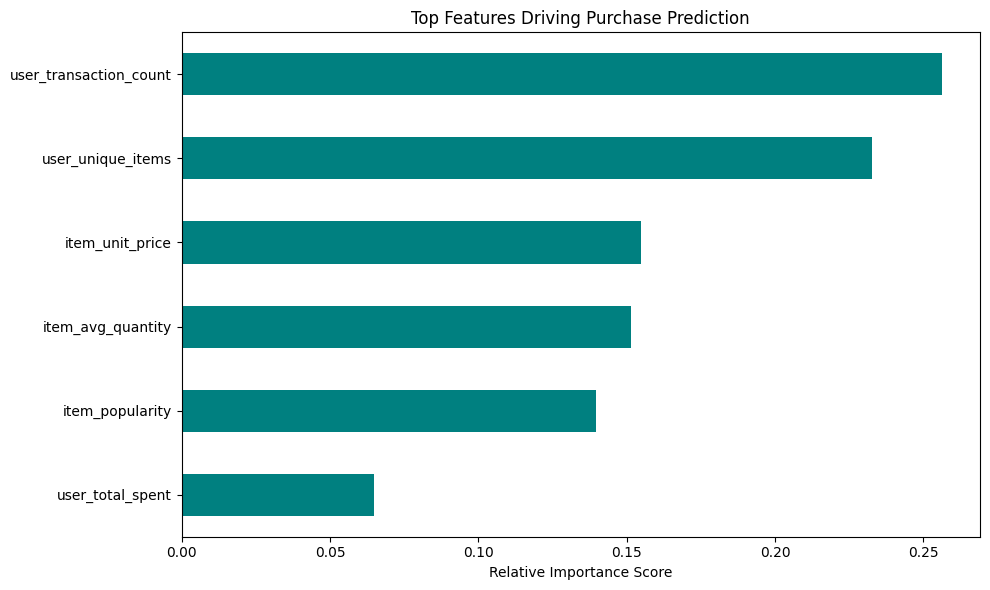

Final optimized model saved to: final_purchase_model.joblib


In [122]:


# 1. Visualize Feature Importance
plt.figure(figsize=(10, 6))
feat_importances = pd.Series(best_model_final.feature_importances_, index=X_train.columns)
feat_importances.nlargest(10).sort_values().plot(kind='barh', color='teal')
plt.title('Top Features Driving Purchase Prediction')
plt.xlabel('Relative Importance Score')
plt.tight_layout()
plt.show()

# 2. Save Final Optimized Model (Renamed without v1)
final_model_path = 'final_purchase_model.joblib'
joblib.dump(best_model_final, final_model_path)
print(f"Final optimized model saved to: {final_model_path}")